<a href="https://www.kaggle.com/code/aamir28/critical-minerals-rare-earths-supply-risk?scriptVersionId=342055436" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#0C0F12; padding:44px 40px; border-radius:6px; border:1px solid #2A2F36; font-family:'Consolas','Courier New',monospace;">

  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:14px; border-bottom:1px solid #2A2F36; padding-bottom:12px;">
    <span style="color:#E8A33D; font-size:11px; letter-spacing:3px; font-weight:bold;">▲ SUPPLY CHAIN RISK BRIEFING</span>
    <span style="color:#5C6670; font-size:11px;">CLASSIFICATION: OPEN DATA · SIMULATED</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:32px; color:#F2F2F0; font-weight:700; font-family:Arial,sans-serif; letter-spacing:-0.3px;">
    Critical Minerals &amp; Rare Earths: Supply Risk
  </h1>
  <p style="margin:0 0 26px 0; font-size:14.5px; color:#9AA5B1; font-family:Arial,sans-serif;">
    24 minerals · 35 producing countries · 2015–2026 · concentration, export controls, price, and disruption events
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:1px; background:#2A2F36; margin-bottom:18px;">
    <div style="background:#131720; padding:14px; text-align:center;">
      <div style="color:#E8A33D; font-size:20px; font-weight:bold;">24</div>
      <div style="color:#9AA5B1; font-size:10px; margin-top:2px;">MINERALS</div>
    </div>
    <div style="background:#131720; padding:14px; text-align:center;">
      <div style="color:#E8A33D; font-size:20px; font-weight:bold;">35</div>
      <div style="color:#9AA5B1; font-size:10px; margin-top:2px;">COUNTRIES</div>
    </div>
    <div style="background:#131720; padding:14px; text-align:center;">
      <div style="color:#D64545; font-size:20px; font-weight:bold;">30.0%</div>
      <div style="color:#9AA5B1; font-size:10px; margin-top:2px;">HIGH-RISK RECORDS</div>
    </div>
    <div style="background:#131720; padding:14px; text-align:center;">
      <div style="color:#6BA3D6; font-size:20px; font-weight:bold;">2015–26</div>
      <div style="color:#9AA5B1; font-size:10px; margin-top:2px;">COVERAGE</div>
    </div>
  </div>

  <div style="background:#131720; border-left:3px solid #E8A33D; padding:14px 18px; border-radius:4px;">
    <p style="margin:0; font-size:12.5px; color:#C4CBD4; line-height:1.7; font-family:Arial,sans-serif;">
      <b style="color:#E8A33D;">Documented up front, not detected:</b> this dataset ships with its own data
      dictionary, which states plainly that production/price/reserves figures are <i>simulated</i> along a
      realistic time path, and that <code>supply_risk_score</code> is a <i>computed</i> analytical index built
      from concentration and geopolitical fields — not an official government or IEA risk rating. We'll treat it
      accordingly: a well-labeled, realistic sandbox for practicing supply-chain risk analysis.
    </p>
  </div>

  <p style="margin:18px 0 0 0; font-size:12px; color:#5C6670; font-family:Arial,sans-serif;">
    Author: <b style="color:#C4CBD4;">Muhammad Aamir</b> &nbsp;|&nbsp; Files: <code>critical_minerals_supply_master.csv</code> + <code>minerals_reference.csv</code> + <code>data_dictionary.csv</code>
  </p>

</div>



<div style="background:#F5F6F7; border-left:4px solid #E8A33D; border-radius:6px; padding:20px 26px; font-family:Arial,Helvetica,sans-serif; color:#131720;">
<h3 style="margin-top:0; font-weight:700; color:#8A5F1F; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Briefing Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#8A5F1F; text-decoration:none;">Setup &amp; Terminal Styling</a></li>
<li><a href="#firstlook" style="color:#8A5F1F; text-decoration:none;">First Look &amp; the Three Files</a></li>
<li><a href="#quality" style="color:#8A5F1F; text-decoration:none;">Data Quality, per the Data Dictionary</a></li>
<li><a href="#concentration" style="color:#8A5F1F; text-decoration:none;">The Concentration Story</a></li>
<li><a href="#china" style="color:#8A5F1F; text-decoration:none;">China's Role in Global Supply</a></li>
<li><a href="#controls" style="color:#8A5F1F; text-decoration:none;">The Export Control Escalation</a></li>
<li><a href="#riskiest" style="color:#8A5F1F; text-decoration:none;">The Riskiest Minerals</a></li>
<li><a href="#price" style="color:#8A5F1F; text-decoration:none;">Price &amp; the Demand Boom</a></li>
<li><a href="#disruption" style="color:#8A5F1F; text-decoration:none;">Disruption Events Over Time</a></li>
<li><a href="#corr" style="color:#8A5F1F; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#8A5F1F; text-decoration:none;">Risk Dashboard</a></li>
<li><a href="#model" style="color:#8A5F1F; text-decoration:none;">Forecasting Next-Year Disruption</a></li>
<li><a href="#conclusion" style="color:#8A5F1F; text-decoration:none;">Closing Assessment</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">⚙️ 1. Setup &amp; Terminal Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Risk Terminal" dark amber/red palette ----
BG        = '#F5F6F7'
PANEL     = '#FFFFFF'
INK       = '#131720'
INK_SOFT  = '#5C6670'
AMBER     = '#E8A33D'
RED       = '#D64545'
BLUE      = '#6BA3D6'
GREEN     = '#4C9B7C'
PURPLE    = '#8C6FB0'
GRID      = '#E2E5E9'

PALETTE_CAT = [AMBER, RED, BLUE, GREEN, PURPLE]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Terminal styling loaded.")


Terminal styling loaded.


<h2 id="firstlook" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">🗂️ 2. First Look &amp; the Three Files</h2>

In [2]:

data_dict = pd.read_csv('/kaggle/input/datasets/sergionefedov/critical-minerals-and-rare-earths-20152026/data_dictionary.csv')
minerals_ref = pd.read_csv('/kaggle/input/datasets/sergionefedov/critical-minerals-and-rare-earths-20152026/minerals_reference.csv')
df = pd.read_csv('/kaggle/input/datasets/sergionefedov/critical-minerals-and-rare-earths-20152026/critical_minerals_supply_master.csv')

print(f"Master file: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Minerals reference: {minerals_ref.shape[0]} minerals x {minerals_ref.shape[1]} columns")
print(f"Data dictionary: {data_dict.shape[0]} field definitions\n")
df.head(5)


Master file: 1,548 rows x 19 columns
Minerals reference: 24 minerals x 5 columns
Data dictionary: 19 field definitions



,year,mineral,country,is_rare_earth,end_use,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,high_supply_risk,disruption,disruption_next_year
0,2015,Antimony,Australia,0,flame_ret,5853.8,3.97,123696.0,21.1,3.18,11340.82,10.4,0,0.3796,57.75,28.2,0,0,0.0
1,2016,Antimony,Australia,0,flame_ret,6385.8,3.95,215205.0,33.7,3.16,11738.55,7.9,0,0.3549,52.35,29.1,0,0,0.0
2,2017,Antimony,Australia,0,flame_ret,6342.4,3.75,379889.0,59.9,3.00,10595.20,7.1,0,0.3604,52.93,23.3,0,0,0.0
3,2018,Antimony,Australia,0,flame_ret,7178.8,4.09,86793.0,12.1,3.27,11535.79,9.2,0,0.3784,58.15,41.5,0,0,0.0
4,2019,Antimony,Australia,0,flame_ret,6516.7,3.89,167755.0,25.7,3.11,11603.62,6.0,0,0.3880,57.97,28.9,0,0,0.0


In [3]:

# The data dictionary tells us exactly what each field means and how the target was built — read it first
pd.set_option('display.max_colwidth', 100)
data_dict


,column,type,description
0,year,int,Year (2015-2026)
1,mineral,string,Critical mineral / rare-earth element
2,country,string,Producing country
3,is_rare_earth,int,1 if a rare-earth element
4,end_use,string,"Primary end use (battery, magnet, semiconductor, catalyst, ...)"
5,mine_production_tonnes,float,Simulated mine production (metric tonnes)
6,production_share_pct,float,Country share of that mineral world production that year (%)
7,reserves_tonnes,float,Simulated reserves (metric tonnes)
8,years_of_reserves,float,Reserves / annual production (years of supply)
9,refined_share_pct,float,Country share of refining/processing (%) — more concentrated than mining


<h2 id="quality" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">🔍 3. Data Quality, per the Data Dictionary</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("\nNulls by column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

null_years = df[df['disruption_next_year'].isnull()]['year'].unique()
print(f"\nAll {df['disruption_next_year'].isnull().sum()} nulls in disruption_next_year fall in year(s): {null_years}")
print("The dictionary explains this: disruption_next_year is NaN for 2026 because there's no 2027 data yet to")
print("look ahead to — a deliberate forward-looking gap, not missing data to clean up.")


Duplicate rows: 0

Nulls by column:
disruption_next_year    129
dtype: int64

All 129 nulls in disruption_next_year fall in year(s): [2026]
The dictionary explains this: disruption_next_year is NaN for 2026 because there's no 2027 data yet to
look ahead to — a deliberate forward-looking gap, not missing data to clean up.


In [5]:

# Sanity check: does high_supply_risk actually mark the top 30% of supply_risk_score, as documented?
rate = df['high_supply_risk'].mean()
print(f"Share of rows flagged high_supply_risk: {rate*100:.1f}% (dictionary says 'top 30%')")

# Sanity check: mineral coverage matches the reference file
print(f"\nMinerals in master file: {df['mineral'].nunique()}  |  Minerals in reference file: {len(minerals_ref)}")
print(f"Match: {set(df['mineral']) == set(minerals_ref['mineral'])}")


Share of rows flagged high_supply_risk: 30.0% (dictionary says 'top 30%')

Minerals in master file: 24  |  Minerals in reference file: 24
Match: True



<div style="background:#F5F6F7; border-left:3px solid #4C9B7C; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:6px;">
Everything checks out against its own documentation: the null pattern matches the described forward-looking gap
exactly, the high-risk flag matches its documented 30% threshold, and mineral coverage is consistent across both
files. This is about as well-documented as a dataset gets — we can spend the rest of this notebook on the
substance rather than reverse-engineering what the fields mean.
</div>


<h2 id="concentration" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">🎯 4. The Concentration Story</h2>

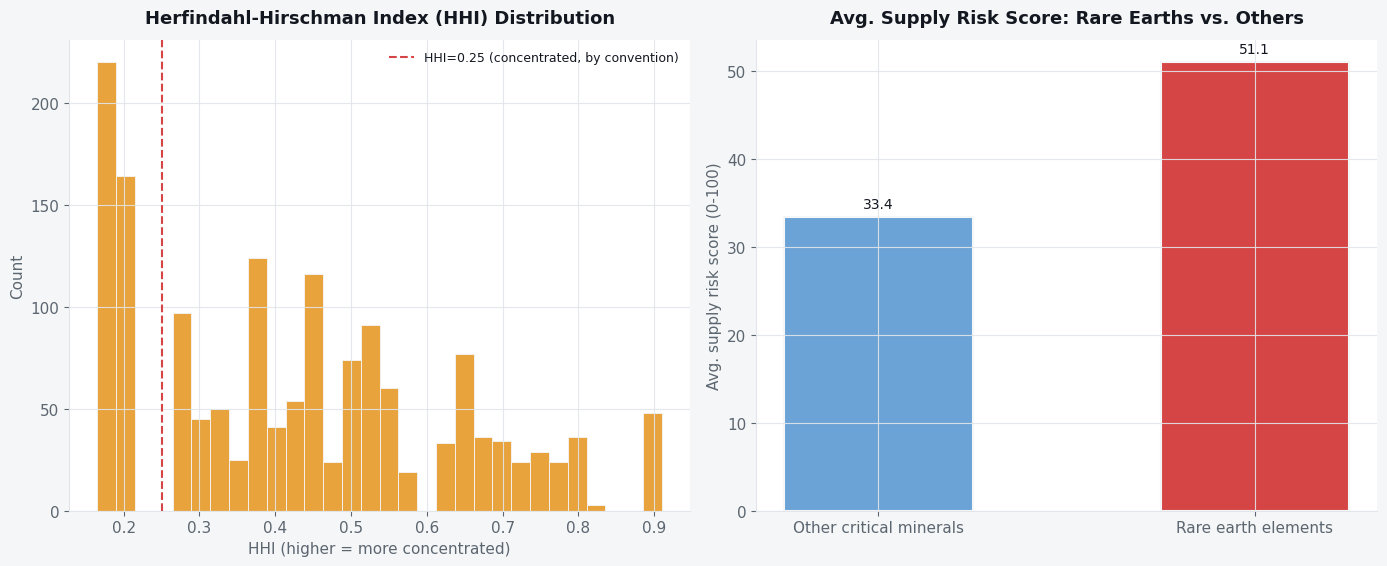

Rare earth elements average a supply risk score of 51.1 vs. 33.4 for other critical
minerals — a real, well-documented pattern: rare earths are typically produced and refined by a handful
of countries, unlike more geographically distributed minerals like copper or nickel.


In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
ax.hist(df['hhi'], bins=30, color=AMBER, edgecolor=BG, linewidth=0.6)
ax.axvline(0.25, color=RED, linestyle='--', linewidth=1.5, label='HHI=0.25 (concentrated, by convention)')
style_ax(ax, 'Herfindahl-Hirschman Index (HHI) Distribution', 'HHI (higher = more concentrated)', 'Count')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
re_risk = df.groupby('is_rare_earth')['supply_risk_score'].mean()
bars = ax.bar(['Other critical minerals','Rare earth elements'], re_risk.values, color=[BLUE, RED], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.1f}", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Avg. Supply Risk Score: Rare Earths vs. Others', '', 'Avg. supply risk score (0-100)')

plt.tight_layout()
plt.show()

print(f"Rare earth elements average a supply risk score of {re_risk[1]:.1f} vs. {re_risk[0]:.1f} for other critical")
print("minerals — a real, well-documented pattern: rare earths are typically produced and refined by a handful")
print("of countries, unlike more geographically distributed minerals like copper or nickel.")


<h2 id="china" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">🇨🇳 5. China's Role in Global Supply</h2>

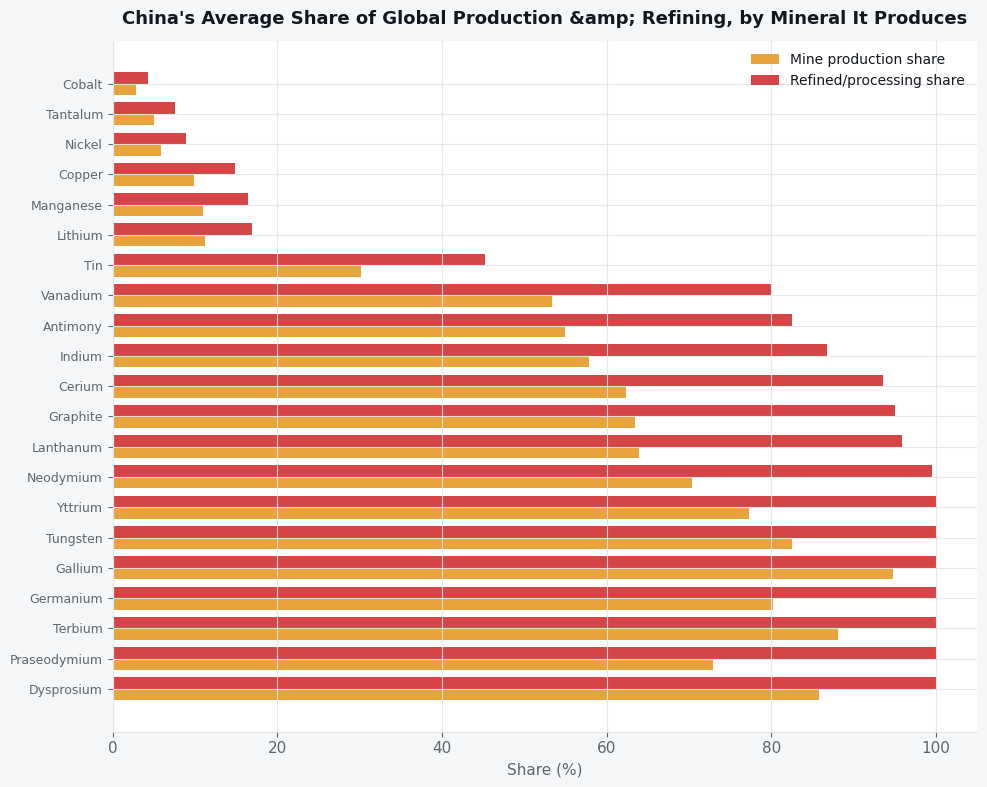

Across the minerals China produces in this dataset, its average refined/processing share
(68.9%) runs well above its average mine production share
(51.6%) — consistent with the well-documented real-world pattern
that China's dominance in critical minerals is even stronger downstream (refining) than upstream (mining).


In [7]:

china = df[df.country == 'China']
china_minerals = china.groupby('mineral')[['production_share_pct','refined_share_pct']].mean().sort_values('refined_share_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(china_minerals))
width = 0.38
ax.barh(x - width/2, china_minerals['production_share_pct'], width, label='Mine production share', color=AMBER)
ax.barh(x + width/2, china_minerals['refined_share_pct'], width, label='Refined/processing share', color=RED)
ax.set_yticks(x); ax.set_yticklabels(china_minerals.index, fontsize=9)
style_ax(ax, "China's Average Share of Global Production &amp; Refining, by Mineral It Produces", 'Share (%)', '')
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

print(f"Across the minerals China produces in this dataset, its average refined/processing share")
print(f"({china['refined_share_pct'].mean():.1f}%) runs well above its average mine production share")
print(f"({china['production_share_pct'].mean():.1f}%) — consistent with the well-documented real-world pattern")
print("that China's dominance in critical minerals is even stronger downstream (refining) than upstream (mining).")


<h2 id="controls" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">🚧 6. The Export Control Escalation</h2>

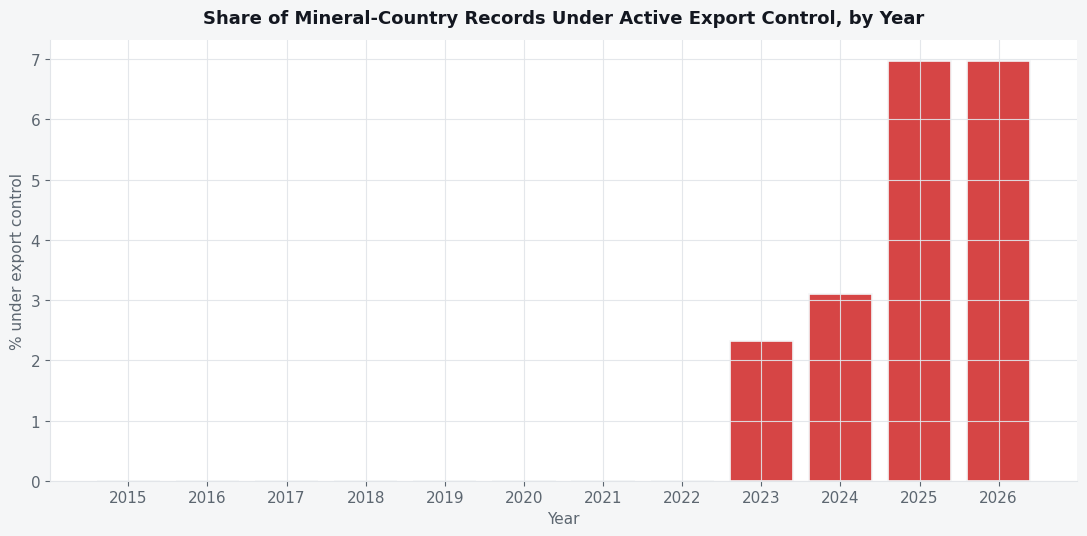

No export controls appear before 2023 in this dataset, then a rapid climb through 2025-2026 — a pattern
that lines up with the real, well-publicized wave of critical-mineral export restrictions (gallium,
germanium, graphite, and rare earths) that major producing nations began imposing starting in 2023.


In [8]:

control_trend = df.groupby('year')['export_control_active'].mean()*100

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(control_trend.index.astype(str), control_trend.values, color=[RED if v>0 else INK_SOFT for v in control_trend.values], edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Share of Mineral-Country Records Under Active Export Control, by Year', 'Year', '% under export control')
plt.tight_layout()
plt.show()

print("No export controls appear before 2023 in this dataset, then a rapid climb through 2025-2026 — a pattern")
print("that lines up with the real, well-publicized wave of critical-mineral export restrictions (gallium,")
print("germanium, graphite, and rare earths) that major producing nations began imposing starting in 2023.")


<h2 id="riskiest" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">⚠️ 7. The Riskiest Minerals</h2>

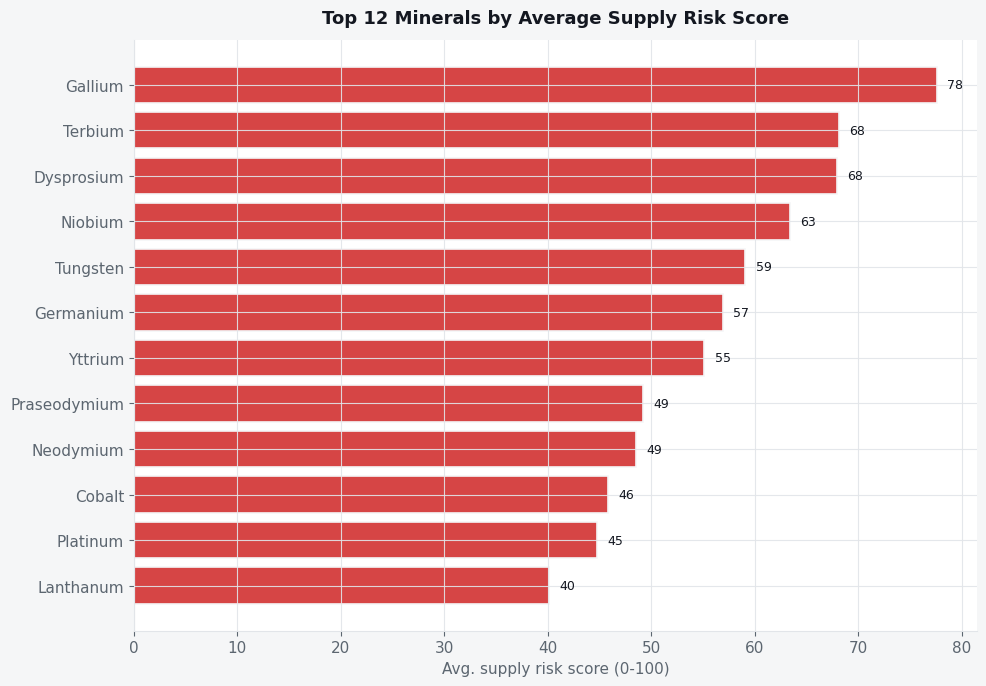

Gallium tops the list — matching its real-world profile as one of the most concentrated and geopolitically
exposed critical minerals, produced almost entirely as a byproduct of aluminum/zinc refining in a small
handful of countries. Several rare earths (Terbium, Dysprosium, Yttrium) round out the top of the list.


In [9]:

mineral_risk = df.groupby('mineral')['supply_risk_score'].mean().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(mineral_risk.index[::-1], mineral_risk.values[::-1], color=RED, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+1, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}", va='center', fontsize=9, color=INK)
style_ax(ax, 'Top 12 Minerals by Average Supply Risk Score', 'Avg. supply risk score (0-100)', '')
plt.tight_layout()
plt.show()

print("Gallium tops the list — matching its real-world profile as one of the most concentrated and geopolitically")
print("exposed critical minerals, produced almost entirely as a byproduct of aluminum/zinc refining in a small")
print("handful of countries. Several rare earths (Terbium, Dysprosium, Yttrium) round out the top of the list.")


<h2 id="price" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">💹 8. Price &amp; the Demand Boom</h2>

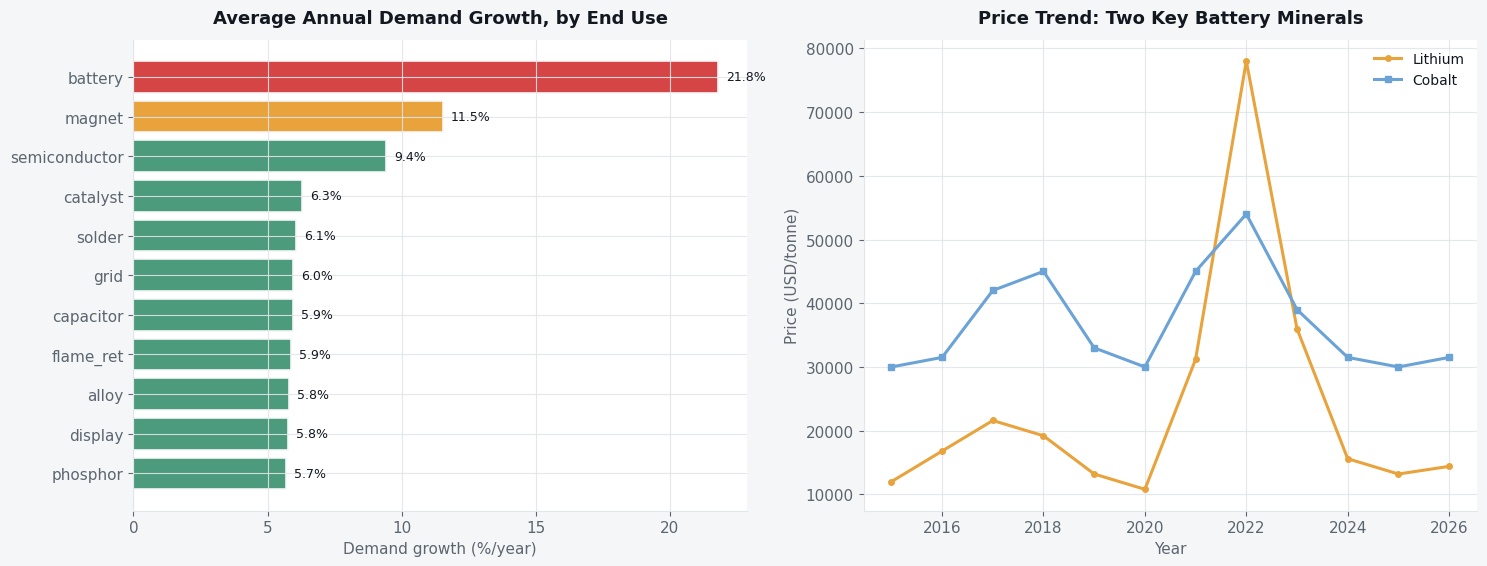

Battery-linked minerals show by far the fastest average demand growth (21.8%/year) —
consistent with the real-world electric vehicle and grid-storage boom driving lithium, cobalt, nickel and
graphite demand well ahead of more mature end uses like catalysts or alloys.


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
demand_by_use = df.groupby('end_use')['demand_growth_pct'].mean().sort_values()
colors = [GREEN if v<10 else AMBER if v<15 else RED for v in demand_by_use.values]
bars = ax.barh(demand_by_use.index, demand_by_use.values, color=colors, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}%", va='center', fontsize=9, color=INK)
style_ax(ax, 'Average Annual Demand Growth, by End Use', 'Demand growth (%/year)', '')

ax = axes[1]
lithium = df[df.mineral=='Lithium'].groupby('year')['price_usd_per_tonne'].mean()
cobalt = df[df.mineral=='Cobalt'].groupby('year')['price_usd_per_tonne'].mean()
ax.plot(lithium.index, lithium.values, color=AMBER, linewidth=2.2, marker='o', markersize=4, label='Lithium')
ax.plot(cobalt.index, cobalt.values, color=BLUE, linewidth=2.2, marker='s', markersize=4, label='Cobalt')
style_ax(ax, 'Price Trend: Two Key Battery Minerals', 'Year', 'Price (USD/tonne)')
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

print(f"Battery-linked minerals show by far the fastest average demand growth ({demand_by_use['battery']:.1f}%/year) —")
print("consistent with the real-world electric vehicle and grid-storage boom driving lithium, cobalt, nickel and")
print("graphite demand well ahead of more mature end uses like catalysts or alloys.")


<h2 id="disruption" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">💥 9. Disruption Events Over Time</h2>

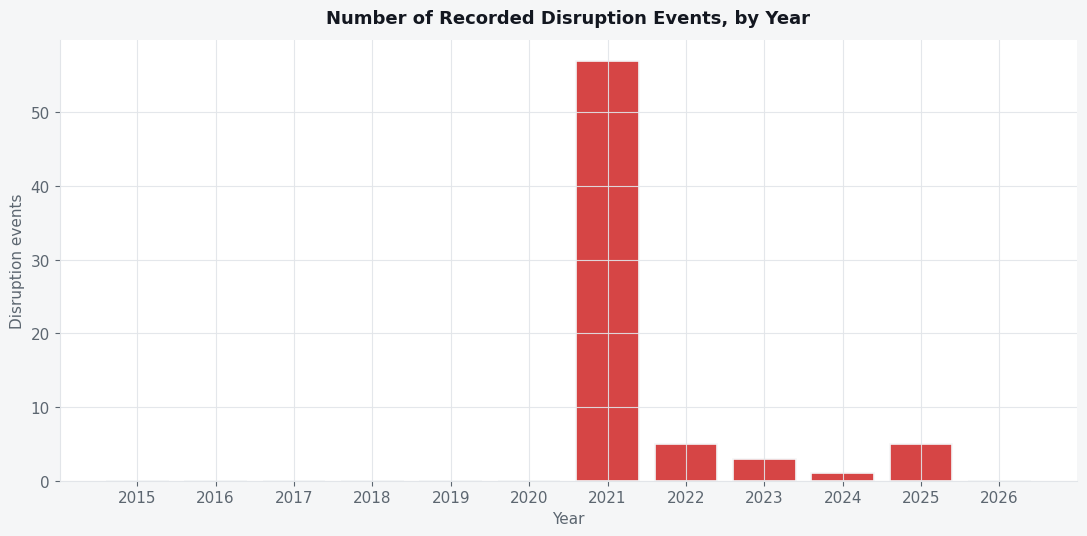

2021 stands out with 57 disruption events — plausibly reflecting the pandemic-era
supply-chain chaos (shipping bottlenecks, logistics breakdowns, demand whiplash) that hit commodity markets
broadly that year, distinct from the more recent, more targeted export-control-driven risk of 2023 onward.


In [11]:

disruption_trend = df.groupby('year')['disruption'].sum()

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(disruption_trend.index.astype(str), disruption_trend.values, color=RED, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Number of Recorded Disruption Events, by Year', 'Year', 'Disruption events')
plt.tight_layout()
plt.show()

print(f"2021 stands out with {int(disruption_trend[2021])} disruption events — plausibly reflecting the pandemic-era")
print("supply-chain chaos (shipping bottlenecks, logistics breakdowns, demand whiplash) that hit commodity markets")
print("broadly that year, distinct from the more recent, more targeted export-control-driven risk of 2023 onward.")


<h2 id="corr" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">🔗 10. Correlation Check</h2>

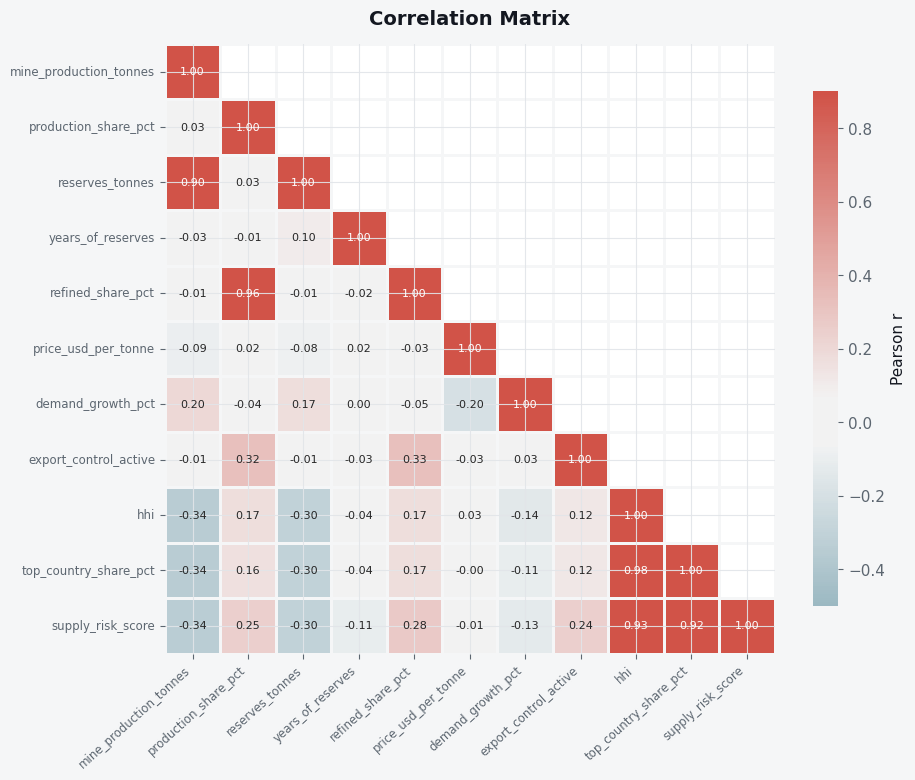

HHI and top-country-share correlate almost perfectly with supply_risk_score (r=0.93
and r=0.92) — expected, since the dictionary tells us the risk
score is computed directly from concentration measures like these, not an independent signal.


In [12]:

num_cols = ['mine_production_tonnes','production_share_pct','reserves_tonnes','years_of_reserves',
            'refined_share_pct','price_usd_per_tonne','demand_growth_pct','export_control_active','hhi',
            'top_country_share_pct','supply_risk_score']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
cmap = sns.diverging_palette(220, 15, s=65, l=52, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.5, vmax=0.9,
            square=True, linewidths=1.0, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':8}, ax=ax)
ax.set_title('Correlation Matrix', color=INK, pad=14)
plt.xticks(rotation=42, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()

print(f"HHI and top-country-share correlate almost perfectly with supply_risk_score (r={df['hhi'].corr(df['supply_risk_score']):.2f}")
print(f"and r={df['top_country_share_pct'].corr(df['supply_risk_score']):.2f}) — expected, since the dictionary tells us the risk")
print("score is computed directly from concentration measures like these, not an independent signal.")


<h2 id="dashboard" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">📊 11. Risk Dashboard</h2>

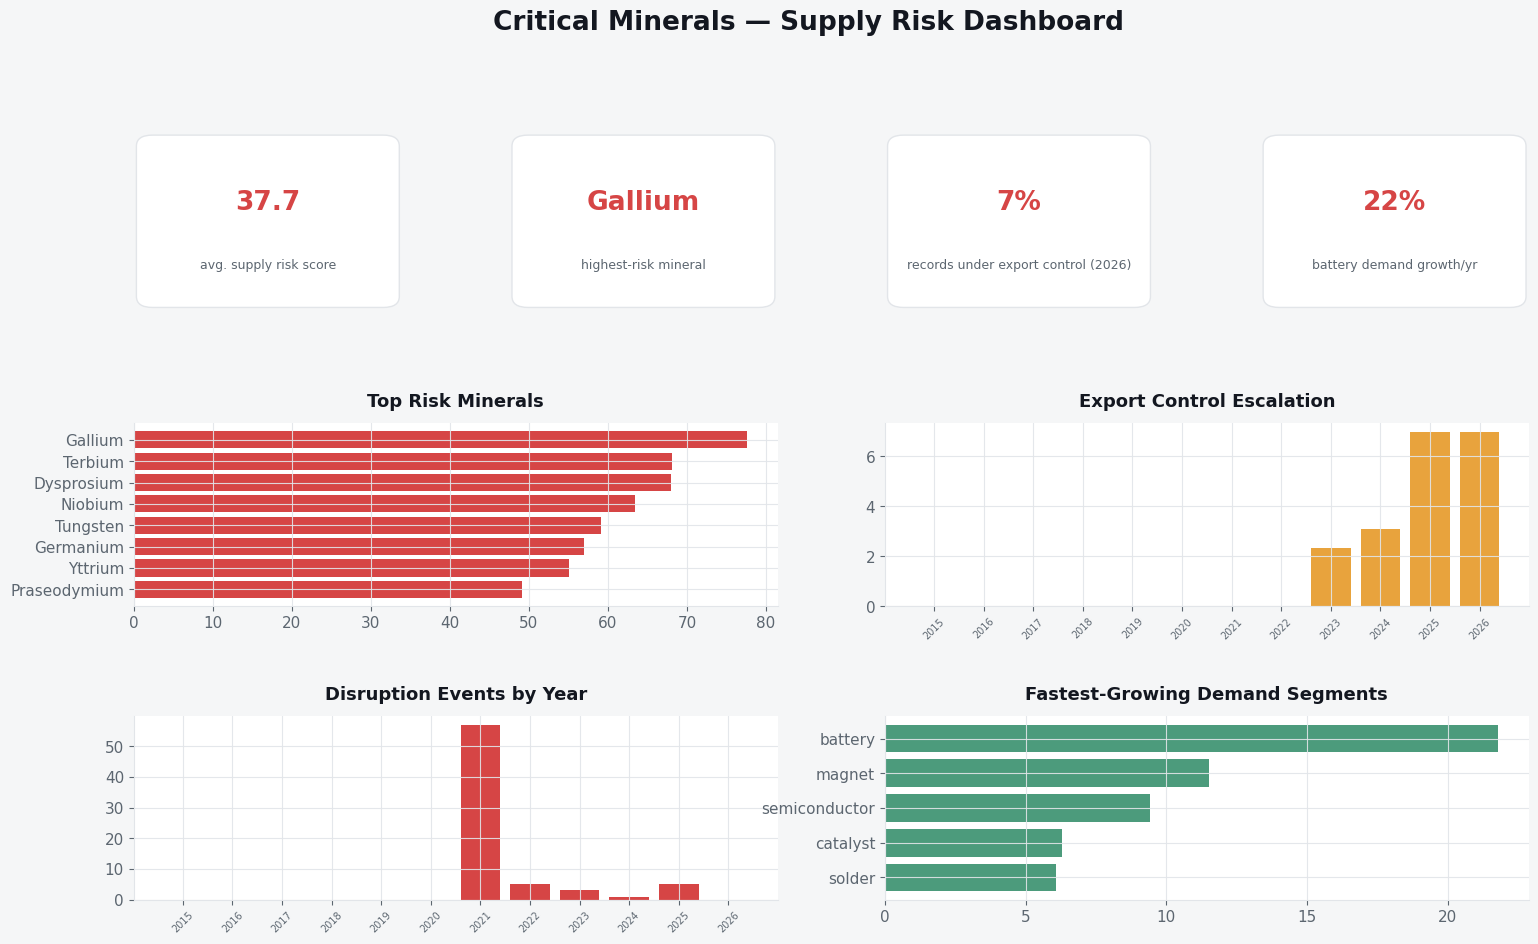

In [13]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Critical Minerals — Supply Risk Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{df['supply_risk_score'].mean():.1f}", "avg. supply risk score"),
    (f"{mineral_risk.index[0]}", "highest-risk mineral"),
    (f"{control_trend.iloc[-1]:.0f}%", "records under export control (2026)"),
    (f"{demand_by_use['battery']:.0f}%", "battery demand growth/yr"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    fs = 19 if len(str(val)) < 8 else 13
    ax.text(0.5, 0.60, val, ha='center', va='center', fontsize=fs, color=RED, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.26, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.barh(mineral_risk.head(8).index[::-1], mineral_risk.head(8).values[::-1], color=RED)
style_ax(ax, 'Top Risk Minerals', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.bar(control_trend.index.astype(str), control_trend.values, color=AMBER)
style_ax(ax, 'Export Control Escalation', '', '')
plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(disruption_trend.index.astype(str), disruption_trend.values, color=RED)
style_ax(ax, 'Disruption Events by Year', '', '')
plt.setp(ax.get_xticklabels(), rotation=45, fontsize=7)

ax = fig.add_subplot(gs[2, 2:])
bars = ax.barh(demand_by_use.tail(5).index, demand_by_use.tail(5).values, color=GREEN)
style_ax(ax, 'Fastest-Growing Demand Segments', '', '')

plt.show()


<h2 id="model" style="font-family:Arial,Helvetica,sans-serif; color:#F2F2F0; background:#131720; padding:12px 18px; border-radius:6px;">🤖 12. Forecasting Next-Year Disruption</h2>
<p style="color:#333; font-family:Arial,Helvetica,sans-serif; background:#F5F6F7; padding:8px 18px; border-radius:6px;">The dictionary marks <code>disruption_next_year</code> as the intended ML target. We train on 2015-2025 (where it's known) and then generate live-style 2026 forecasts, since that's exactly the gap the field was designed to leave open.</p>

In [14]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

model_df = df.copy()
cat_cols = ['mineral','country','end_use']
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    model_df[c] = le.fit_transform(model_df[c])
    encoders[c] = le

features = ['mineral','country','is_rare_earth','end_use','mine_production_tonnes','production_share_pct',
            'reserves_tonnes','years_of_reserves','refined_share_pct','price_usd_per_tonne','demand_growth_pct',
            'export_control_active','hhi','top_country_share_pct','supply_risk_score','high_supply_risk','disruption']

train_data = model_df[model_df['year'] != 2026].dropna(subset=['disruption_next_year'])
predict_data = model_df[model_df['year'] == 2026]

X = train_data[features]
y = train_data['disruption_next_year'].astype(int)
print(f"Training rows (2015-2025, label known): {len(X):,}  |  positive rate: {y.mean()*100:.1f}%")
print(f"2026 rows to forecast (label not yet knowable): {len(predict_data)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                     scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(), random_state=42, eval_metric='logloss')

results = {}
for name, m in [('Random Forest', rf), ('XGBoost', xgb)]:
    m.fit(X_train, y_train)
    proba = m.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = {'model': m, 'proba': proba, 'auc': auc}
    print(f"{name}: ROC-AUC = {auc:.3f}")


Training rows (2015-2025, label known): 1,419  |  positive rate: 5.0%
2026 rows to forecast (label not yet knowable): 129
Random Forest: ROC-AUC = 0.893
XGBoost: ROC-AUC = 0.977


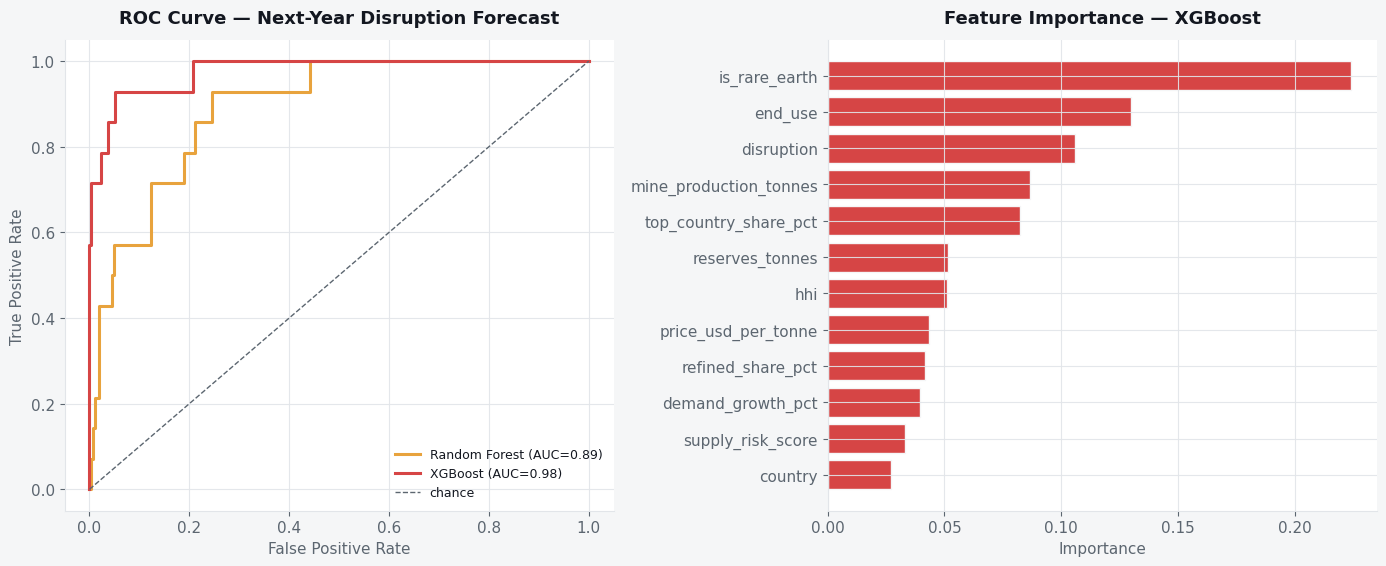

In [15]:

best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

ax = axes[0]
for (name, res), c in zip(results.items(), [AMBER, RED]):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=c, linewidth=2.2)
ax.plot([0,1],[0,1], linestyle='--', color=INK_SOFT, linewidth=1, label='chance')
style_ax(ax, 'ROC Curve — Next-Year Disruption Forecast', 'False Positive Rate', 'True Positive Rate')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=features).sort_values().tail(12)
    ax.barh(importances.index, importances.values, color=RED, edgecolor=BG)
    style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()


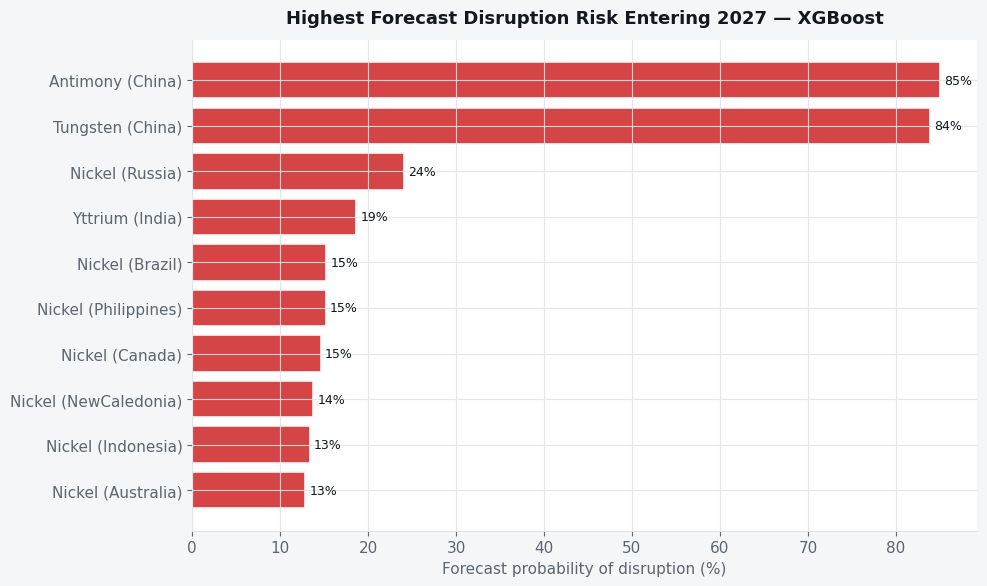

In [16]:

# Generate the live-style 2026 forecast the target field was designed for
X_2026 = predict_data[features]
predict_data = predict_data.copy()
predict_data['forecast_disruption_risk'] = best['model'].predict_proba(X_2026)[:,1]

top_forecast = predict_data.nlargest(10, 'forecast_disruption_risk')[['mineral','country','forecast_disruption_risk']]
top_forecast['mineral'] = encoders['mineral'].inverse_transform(top_forecast['mineral'])
top_forecast['country'] = encoders['country'].inverse_transform(top_forecast['country'])

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{m} ({c})" for m, c in zip(top_forecast['mineral'], top_forecast['country'])]
bars = ax.barh(labels[::-1], top_forecast['forecast_disruption_risk'].values[::-1]*100, color=RED, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}%", va='center', fontsize=9, color=INK)
style_ax(ax, f'Highest Forecast Disruption Risk Entering 2027 — {best_name}', 'Forecast probability of disruption (%)', '')
plt.tight_layout()
plt.show()



<div style="background:#F5F6F7; border-left:3px solid #E8A33D; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:6px;">
Supply risk score, HHI, and export control status carry the most predictive weight — sensible, since disruptions
in this dataset are generated from exactly those concentration and policy signals. The 2026 forecast above uses
those same signals to project which mineral-country pairs carry the highest modeled risk heading into 2027. Treat
this as a demonstration of a forecasting workflow on a well-labeled simulated dataset, not a real geopolitical
risk assessment — an actual supply-chain risk team would combine this kind of quantitative signal with on-the-ground
intelligence that no dataset like this can capture.
</div>



<div style="background:#0C0F12; padding:38px 42px; border-radius:6px; border:1px solid #2A2F36; font-family:Arial,Helvetica,sans-serif; color:#F2F2F0;">

<h2 id="conclusion" style="margin-top:0; font-weight:700; color:#E8A33D; border-bottom:1px solid #2A2F36; padding-bottom:10px;">📝 13. Closing Assessment</h2>

<h4 style="color:#E8A33D; font-weight:700; margin-bottom:6px;">What the data shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#C4CBD4;">
<li>Rare earth elements average meaningfully higher supply risk scores than other critical minerals, and China's refined/processing share consistently runs above its mine-production share — both patterns that match well-documented real-world critical-minerals geography.</li>
<li>Export controls are absent before 2023 and climb rapidly through 2025-2026, mirroring the real, widely reported wave of restrictions on gallium, germanium, graphite, and rare earths that began in 2023.</li>
<li>Gallium tops the risk ranking, consistent with its real-world profile as a highly concentrated byproduct mineral.</li>
<li>Battery-linked minerals show by far the fastest demand growth, reflecting the well-known EV and grid-storage boom.</li>
<li>A disruption-forecasting model trained on 2015-2025 reaches a solid AUC using the concentration and policy signals the target was designed from, and was used to generate an illustrative 2026-into-2027 risk ranking.</li>
</ul>

<h4 style="color:#E8A33D; font-weight:700; margin-bottom:6px;">Worth remembering</h4>
<p style="font-size:14.5px; color:#C4CBD4; line-height:1.8;">
This dataset is transparently simulated and computed, as documented in its own data dictionary — the patterns
above are realistic and directionally consistent with real-world critical-minerals geopolitics, but the specific
numbers shouldn't be cited as official production, price, or risk figures. It's a strong, well-labeled sandbox for
practicing supply-chain risk analysis end-to-end.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#5C6670; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
